# Example: Layout Visualizations

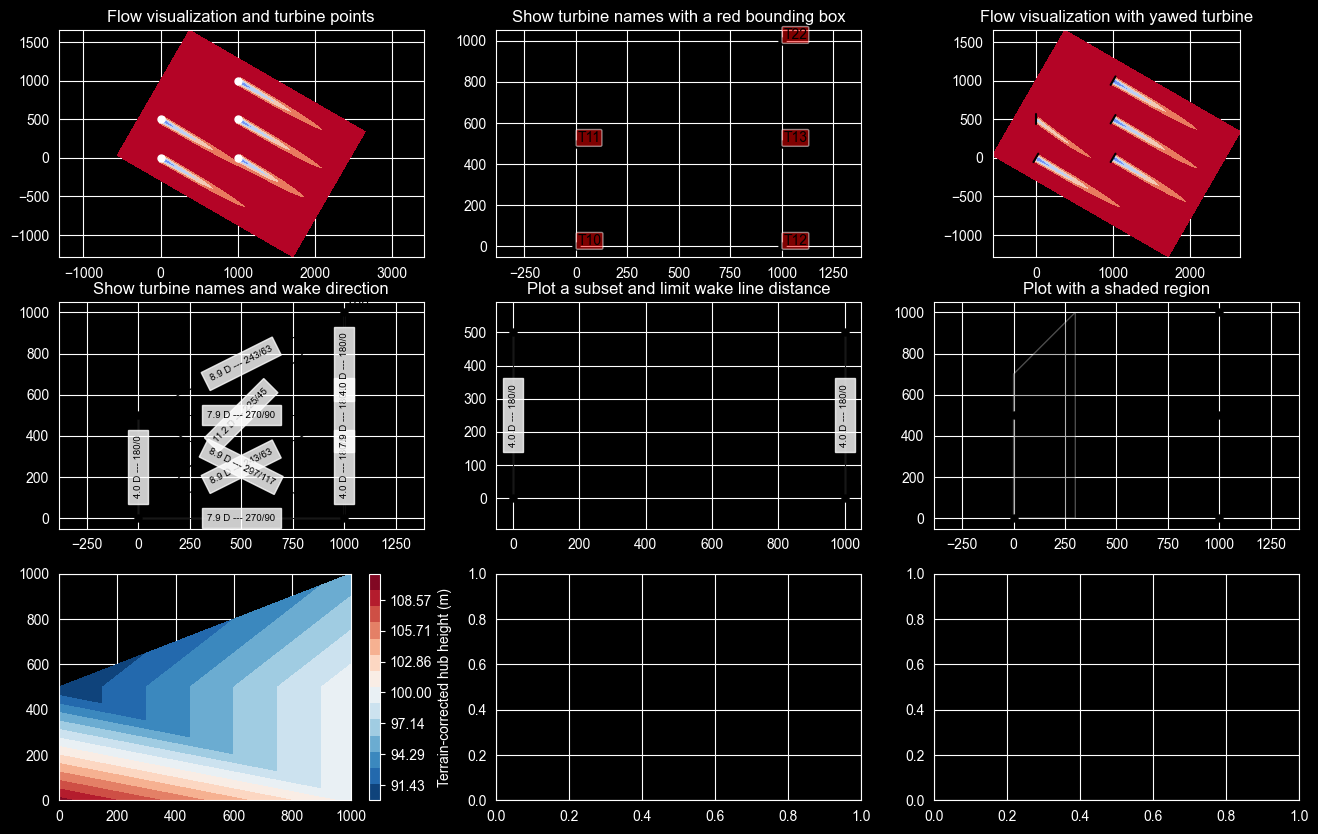

In [1]:
"""Example: Layout Visualizations

Demonstrate the use of all the functions within the layout_visualization module

"""

import matplotlib.pyplot as plt
import numpy as np

import floris.layout_visualization as layoutviz
from floris import FlorisModel
from floris.flow_visualization import visualize_cut_plane


# Create the plotting objects using matplotlib
fig, axarr = plt.subplots(3, 3, figsize=(16, 10), sharex=False)
axarr = axarr.flatten()

MIN_WS = 1.0
MAX_WS = 8.0

# Initialize FLORIS with the given input file.
fmodel = FlorisModel("../inputs/gch.yaml")

# Change to 5-turbine layout with a wind direction from northwest
fmodel.set(
    layout_x=[0, 0, 1000, 1000, 1000], layout_y=[0, 500, 0, 500, 1000], wind_directions=[300]
)

# Plot 1: Visualize the flow
ax = axarr[0]
# Plot a horizatonal slice of the initial configuration
horizontal_plane = fmodel.calculate_horizontal_plane(height=90.0)
visualize_cut_plane(
    horizontal_plane,
    ax=ax,
    min_speed=MIN_WS,
    max_speed=MAX_WS,
)
# Plot the turbine points, setting the color to white
layoutviz.plot_turbine_points(fmodel, ax=ax, plotting_dict={"color": "w"})
ax.set_title("Flow visualization and turbine points")

# Plot 2: Show a particular flow case
ax = axarr[1]
turbine_names = [f"T{i}" for i in [10, 11, 12, 13, 22]]
layoutviz.plot_turbine_points(fmodel, ax=ax)
layoutviz.plot_turbine_labels(
    fmodel, ax=ax, turbine_names=turbine_names, show_bbox=True, bbox_dict={"facecolor": "r"}
)
ax.set_title("Show turbine names with a red bounding box")


# Plot 2: Show turbine rotors on flow
ax = axarr[2]
fmodel.set(yaw_angles=np.array([[0., 30., 0., 0., 0.]]))
horizontal_plane = fmodel.calculate_horizontal_plane(height=90.0)
visualize_cut_plane(horizontal_plane, ax=ax, min_speed=MIN_WS, max_speed=MAX_WS)
layoutviz.plot_turbine_rotors(fmodel, ax=ax, yaw_angles=np.array([[0.0, 30.0, 0.0, 0.0, 0.0]]))
ax.set_title("Flow visualization with yawed turbine")

# Plot 3: Show the layout, including wake directions
ax = axarr[3]
layoutviz.plot_turbine_points(fmodel, ax=ax)
layoutviz.plot_turbine_labels(fmodel, ax=ax, turbine_names=turbine_names)
layoutviz.plot_waking_directions(fmodel, ax=ax)
ax.set_title("Show turbine names and wake direction")

# Plot 4: Plot a subset of the layout, and limit directions less than 7D
ax = axarr[4]
layoutviz.plot_turbine_points(fmodel, ax=ax, turbine_indices=[0, 1, 2, 3])
layoutviz.plot_turbine_labels(
    fmodel, ax=ax, turbine_names=turbine_names, turbine_indices=[0, 1, 2, 3]
)
layoutviz.plot_waking_directions(fmodel, ax=ax, turbine_indices=[0, 1, 2, 3], limit_dist_D=7)
ax.set_title("Plot a subset and limit wake line distance")

# Plot with a shaded region
ax = axarr[5]
layoutviz.plot_turbine_points(fmodel, ax=ax)
layoutviz.shade_region(np.array([[0, 0], [300, 0], [300, 1000], [0, 700]]), ax=ax)
ax.set_title("Plot with a shaded region")

# Change hub heights and plot as a proxy for terrain
ax = axarr[6]
fmodel.core.farm.hub_heights = np.array([110, 90, 100, 100, 95])
layoutviz.plot_farm_terrain(fmodel, ax=ax)

plt.show()
import warnings
warnings.filterwarnings('ignore')